# gamifying cabs

ola cab fares and trip times for all of gurgaon — 207 hexagons, every origin-destination pair, every 30-minute slot of the day. ~2 million rows: 57k measured (ola fares + tomtom traffic times), the rest predicted by a gradient boosting model (pair-held-out r² 0.92).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## load the grid

In [2]:
df = pd.read_parquet("city_grid.parquet")
print(f"{len(df):,} rows")
df.head()

2,046,816 rows


,from_id,to_id,from_name,to_name,slot,dist_km,trip_min,price,source
0,883da10305fffff,883da10309fffff,Faridabad-Gurgaon Road 2,Arjangarh Air Force Station,00:00,1.59,23.2,251.0,predicted
1,883da10305fffff,883da10309fffff,Faridabad-Gurgaon Road 2,Arjangarh Air Force Station,00:30,1.59,22.9,244.0,predicted
2,883da10305fffff,883da10309fffff,Faridabad-Gurgaon Road 2,Arjangarh Air Force Station,01:00,1.59,22.9,245.0,predicted
3,883da10305fffff,883da10309fffff,Faridabad-Gurgaon Road 2,Arjangarh Air Force Station,01:30,1.59,22.9,245.0,predicted
4,883da10305fffff,883da10309fffff,Faridabad-Gurgaon Road 2,Arjangarh Air Force Station,02:00,1.59,22.8,245.0,predicted


In [3]:
df[["dist_km", "trip_min", "price"]].describe().round(1)

,dist_km,trip_min,price
count,2046816.0,2046816.0,2046816.0
mean,6.5,25.5,188.1
std,3.0,9.0,57.9
min,0.9,1.9,70.0
25%,4.2,18.9,144.0
50%,6.4,24.7,178.0
75%,8.8,31.3,221.0
max,15.4,67.3,538.0


## cheapest rides

one row per route (its cheapest slot of the day), so the table isn't 48 copies of the same pair

In [4]:
cols = ["from_name", "to_name", "slot", "dist_km", "trip_min", "price", "source"]

cheapest = df.sort_values("price").drop_duplicates(["from_id", "to_id"])
cheapest[cols].head(10)

,from_name,to_name,slot,dist_km,trip_min,price,source
1301891,Worldmark,Sector 67 2,17:30,0.92,6.2,70.0,measured
597058,Sector 48,Club Walk,17:00,0.92,6.3,70.0,measured
734679,Tulip Purple,Golf Course Extension Road,19:30,0.92,7.3,70.0,measured
1321330,Golf Course Extension Road 2,Sector 65,17:00,0.92,3.5,70.0,measured
297922,Palam Vihar,Ashok Vihar Phase III Extension 2,17:00,0.92,6.8,70.0,measured
1231187,Metro Mall Road,Golf Course Road 2,17:30,0.92,7.4,70.0,measured
367474,Palam Vihar Extension,Noble Enclave,17:00,0.92,9.1,70.0,measured
1381863,Pataudi Road,HUDA 3,19:30,0.92,4.9,70.0,measured
387351,Palam Vihar Extension 2,Block A,19:30,0.92,18.2,70.0,measured
774898,Sector 67,Badshahpur,17:00,0.92,6.2,70.0,measured


## most expensive rides

each route at its priciest slot

In [5]:
priciest = df.sort_values("price", ascending=False).drop_duplicates(["from_id", "to_id"])
priciest[cols].head(10)

,from_name,to_name,slot,dist_km,trip_min,price,source
981380,Almeda,South,10:00,14.54,48.5,538.0,measured
842947,Sector 73,South,09:30,13.63,52.4,536.0,measured
487816,South 2,Espace 2,20:00,11.21,58.0,524.0,measured
1198915,Samaspur Avenue,South,09:30,9.80,39.5,513.0,measured
1277923,Sector 65,South 2,09:30,11.24,49.6,509.0,predicted
1337251,Golf Course Ext Road,South 2,09:30,11.66,52.5,509.0,predicted
734180,Tulip Purple,South,10:00,14.54,47.5,509.0,measured
1109827,Sector 59 4,South 2,09:30,12.42,51.0,508.0,predicted
684643,Espace 2,South 2,09:30,11.21,50.5,508.0,predicted
704515,Mayfield Garden,South,09:30,10.27,41.2,508.0,measured


## most time-taking rides

each route at its slowest slot

In [6]:
slowest = df.sort_values("trip_min", ascending=False).drop_duplicates(["from_id", "to_id"])
slowest[cols].head(10)

,from_name,to_name,slot,dist_km,trip_min,price,source
36373,Faridabad-Gurgaon Road 3,Raj Nagar,18:30,12.62,67.3,330.0,measured
1000600,Sector 58,Palam Vihar Extension 2,20:00,11.59,66.4,289.0,predicted
1118343,Sector 59 5,Sector 110,19:30,14.35,66.1,307.0,measured
389320,Palam Vihar Extension 2,Badshahpur 2,20:00,11.91,65.9,241.0,predicted
1129144,Sector 59 6,Palam Vihar Extension 2,20:00,12.91,65.9,290.0,predicted
999686,Sector 58,Sector 110,19:00,13.43,65.8,292.0,measured
557413,Production test track,Badshahpur 2,18:30,12.41,64.8,276.0,predicted
684755,Espace 2,South,17:30,11.66,64.6,401.0,measured
1119256,Sector 59 5,Palam Vihar Extension 2,20:00,12.51,64.4,298.0,predicted
1109368,Sector 59 4,Palam Vihar Extension 2,20:00,12.61,64.2,281.0,predicted


## shortest rides

each route at its fastest slot

In [7]:
fastest = df.sort_values("trip_min").drop_duplicates(["from_id", "to_id"])
fastest[cols].head(10)

,from_name,to_name,slot,dist_km,trip_min,price,source
188596,Golf Course Road,DLF 5,02:00,0.92,1.9,109.0,measured
1212292,Golf Course Road 3,Sector 55,02:00,0.92,2.2,95.0,measured
1450468,Sector 6,Sector 12,02:00,0.92,2.3,95.0,measured
963744,Sector 75A,Sector 75A 2,00:00,0.96,2.3,96.0,measured
1662100,HUDA Sector 27,Golf Course Road,02:00,0.92,2.5,95.0,measured
1043238,Golf Course Road 2,Sushant Lok 2 Main Road,03:00,0.96,2.5,96.0,measured
1083028,Sector 59 3,Brahma City,02:00,0.92,2.6,95.0,measured
1549492,Sector 3A 2,Sector 4,02:00,0.92,2.6,95.0,measured
1092916,Brahma City,Sector 59 3,02:00,0.92,2.6,95.0,measured
962064,Sector 75A,Golf Course Extension Road,00:00,0.96,2.7,96.0,measured


## when to ride

city-wide average price and trip time by time of day

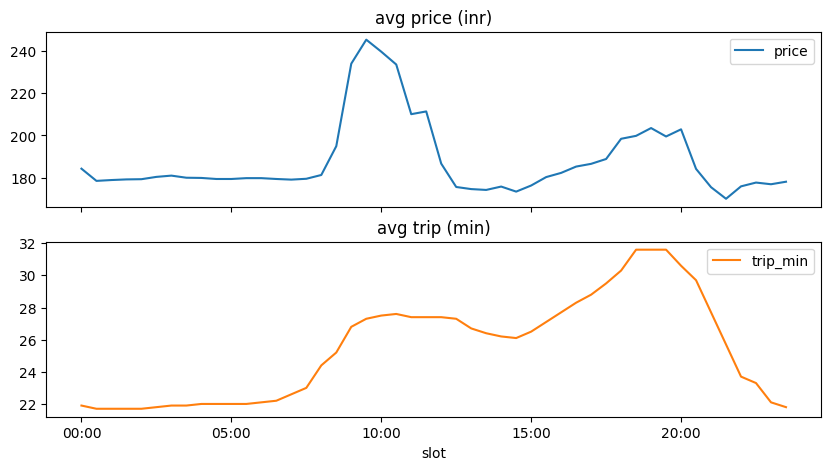

In [8]:
by_slot = df.groupby("slot")[["price", "trip_min"]].mean().round(1)
by_slot.plot(subplots=True, figsize=(10, 5), title=["avg price (inr)", "avg trip (min)"]);

## price vs distance

fares scale with distance but fan out — the spread at a given distance is traffic and time of day

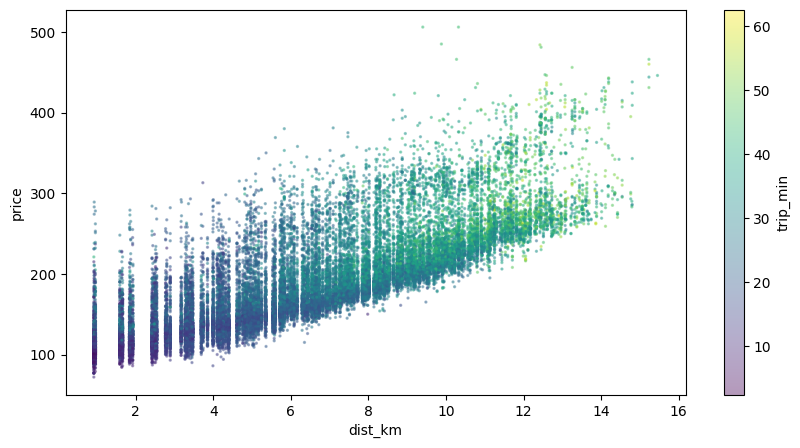

In [9]:
s = df.sample(30000, random_state=0)
s.plot.scatter(x="dist_km", y="price", c="trip_min", cmap="viridis", s=2, alpha=0.4, figsize=(10, 5));

## rush hour premium

for every route: its 6-8 pm average price vs its 2-4 am average — how much extra the evening peak costs

(note: dist_km is straight-line, not road distance — road routes in gurgaon run ~1.5x longer — so no per-km charts here)

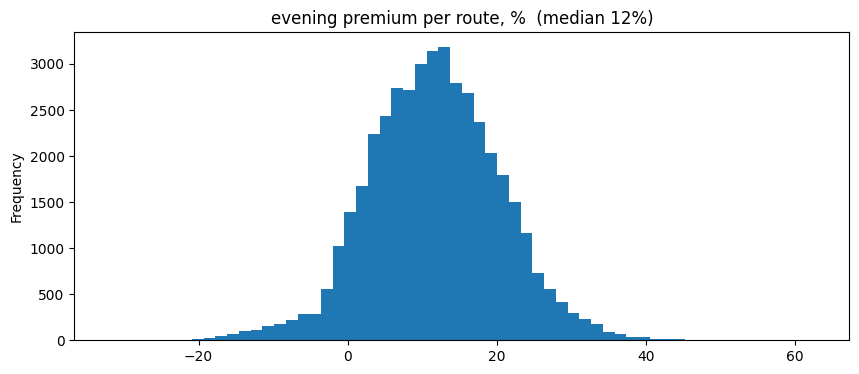

In [10]:
evening = df[df.slot.isin(["18:00", "18:30", "19:00", "19:30"])].groupby(["from_id", "to_id"])["price"].mean()
night = df[df.slot.isin(["02:00", "02:30", "03:00", "03:30"])].groupby(["from_id", "to_id"])["price"].mean()
premium = (evening / night - 1) * 100

premium.plot.hist(bins=60, figsize=(10, 4), title=f"evening premium per route, %  (median {premium.median():.0f}%)");

## priciest and cheapest areas to leave from

average fare for mid-length trips (4-8 km straight-line) by origin, so distance isn't the confound

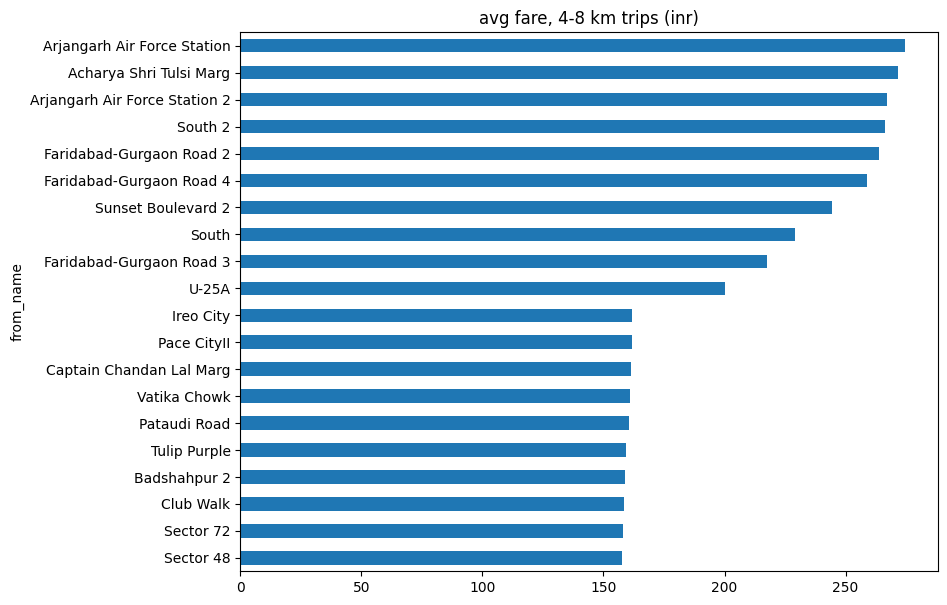

In [11]:
mid = df[df.dist_km.between(4, 8)]
by_origin = mid.groupby("from_name")["price"].mean().sort_values()

pd.concat([by_origin.head(10), by_origin.tail(10)]).plot.barh(figsize=(9, 7), title="avg fare, 4-8 km trips (inr)");

## price heatmap: time of day x trip length

every cell is the average fare for that slot and distance band — the evening ridge shows up clearly on longer trips

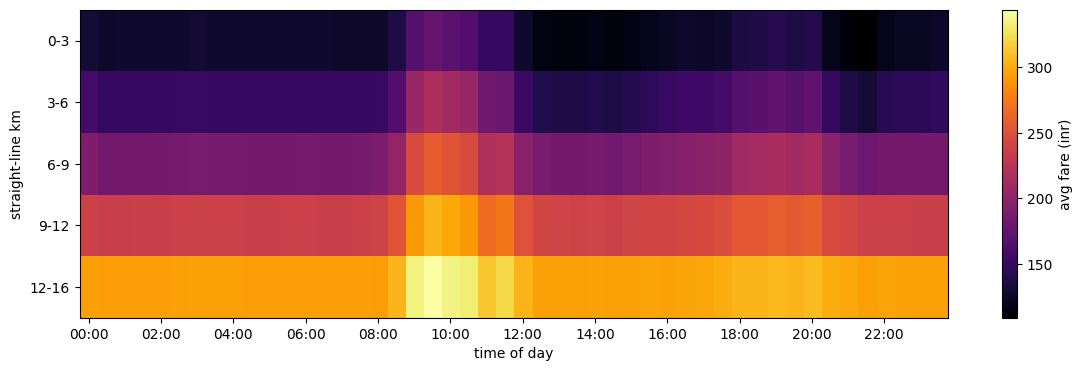

In [12]:
df["band"] = pd.cut(df.dist_km, [0, 3, 6, 9, 12, 16, 25], labels=["0-3", "3-6", "6-9", "9-12", "12-16", "16+"])
heat = df.pivot_table(values="price", index="band", columns="slot", aggfunc="mean", observed=True)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heat, aspect="auto", cmap="inferno")
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xticks(range(0, 48, 4), heat.columns[::4])
ax.set_xlabel("time of day")
ax.set_ylabel("straight-line km")
fig.colorbar(im, label="avg fare (inr)");